In [4]:
# importing the necessary libraries
import pandas as pd  # for data manipulation
from matplotlib import pyplot as plt  # library for creating and visualizing plots
import numpy as np  # for numerical calculations and operations
import seaborn as sns  # for data visualization
from scipy import stats as st  # for advanced statistical calculations if needed


In [5]:
# importing the dataset
df_games = pd.read_csv('games.csv')

In [6]:
#printing the general info about the dataset
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


##### From the preliminary analysis of the dataset and the inspection of its structure, I have the following initial observations: 
1. There are missing values in several columns, and the score-related columns have a significant number of null entries. Since these "scores" play an important role in the required analysis, it will be necessary to define the best strategy to handle these missing values during the data‑cleaning process. 
2. Also detected integrity issues in the dataset, with many values misplaced in the wrong columns.
3. The user_score column should be converted to a float type.
4. Column names should be standardized to lowercase, and it may be necessary to rename some of them to ensure they better reflect the information they represent.

In [22]:
df_games.rename(columns={'Name': 'game_name'}, inplace=True)
#changing column names to lower case
df_games.columns = df_games.columns.str.lower()
df_games.head()

,game_name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [23]:
df_games['year_of_release'].unique() # printing the unique release year values to check how Python interprets missing and non‑numeric entries

array([2006., 1985., 2008., 2009., 1996., 1989., 1984., 2005., 1999.,
       2007., 2010., 2013., 2004., 1990., 1988., 2002., 2001., 2011.,
       1998., 2015., 2012., 2014., 1992., 1997., 1993., 1994., 1982.,
       2016., 2003., 1986., 2000.,   nan, 1995., 1991., 1981., 1987.,
       1980., 1983.])

##### VI noticed that Python interprets missing values and strings as NaN. In total, there are 109 misaligned rows, and 402 rows if we also count the empty cells in 'year_of_release', which is about 2.4% of a dataset with 16,715 entries. Removing these rows will not have a significant impact on the analysis.  
##### Now I will check for duplicate rows before removing the NaN values.


In [24]:
df_games.duplicated().sum() # checking for duplicate entries in the dataset

np.int64(0)

In [27]:
df_games.dropna(subset=['year_of_release'], inplace=True) # removing rows with missing values in the 'year_of_release' column
df_games['year_of_release'] = df_games['year_of_release'].astype(int) # converting the 'year_of_release' column to integer type
df_games.dropna(subset=['game_name'], inplace=True) # removing rows with missing values in the 'game_name' column
df_games.info() # checking the dataset info again to confirm the changes made to the 'game_name' column

<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_name        16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       9839 non-null   object 
 10  rating           9768 non-null   object 
dtypes: float64(5), int64(1), object(5)
memory usage: 1.5+ MB


##### After the first stage of cleaning, the last three columns of the dataset (critic_score, user_score and rating) still contain missing values, which will be handled as follows:  
1. user_score – values marked as 'tbd' will be treated as missing values (NaN), as they represent an undetermined score (absence of information). Then the data will be converted from object to float
2. The missing values in these three columns will not be removed, because dropping these rows would drastically reduce the size of the dataset and introduce significant bias, distorting subsequent analyses.  
3. The missing values will also not be filled with estimates or artificial values, as a limited analysis is preferable to a misleading one that alters means, medians and distributions, further compromising data integrity.

In [ ]:
# replacing the string 'tbd' with Nan values in the 'user_score' column to handle non‑numeric entries
df_games['user_score'] =pd.to_numeric(df_games['user_score'], errors='coerce') # converting the 'user_score' column to float type
df_games.info() # checking the dataset info again to confirm the changes made to the 'user_score' column


<class 'pandas.core.frame.DataFrame'>
Index: 16444 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   game_name        16444 non-null  object 
 1   platform         16444 non-null  object 
 2   year_of_release  16444 non-null  int64  
 3   genre            16444 non-null  object 
 4   na_sales         16444 non-null  float64
 5   eu_sales         16444 non-null  float64
 6   jp_sales         16444 non-null  float64
 7   other_sales      16444 non-null  float64
 8   critic_score     7983 non-null   float64
 9   user_score       7463 non-null   float64
 10  rating           9768 non-null   object 
dtypes: float64(6), int64(1), object(4)
memory usage: 1.5+ MB


In [56]:
# calculating the total amount of sales across all reagions
df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']
print(df_games[['game_name','platform','total_sales']]) # printing the first few values of the 'total_sales' column to confirm the calculation

                           game_name platform  total_sales
0                         Wii Sports      Wii        82.54
1                  Super Mario Bros.      NES        40.24
2                     Mario Kart Wii      Wii        35.52
3                  Wii Sports Resort      Wii        32.77
4           Pokemon Red/Pokemon Blue       GB        31.38
...                              ...      ...          ...
16710  Samurai Warriors: Sanada Maru      PS3         0.01
16711               LMA Manager 2007     X360         0.01
16712        Haitaka no Psychedelica      PSV         0.01
16713               Spirits & Spells      GBA         0.01
16714            Winning Post 8 2016      PSV         0.01

[16444 rows x 3 columns]


In [49]:
num_games_per_year = df_games.groupby('year_of_release')['game_name'].count() # counting the number of games released each year

print(num_games_per_year)


year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: game_name, dtype: int64


##### We have data collected consecutively from 1980 to 2016. In the 1980s and up until 1993, the sample size is very limited, with very few games released each year. From 1994 onwards, the dataset shows a more significant upward trend, and by the late 1990s we already observe more substantial samples, with over 300 releases per year, reaching a peak in 2008 and 2009 according to the available data. This trend may be linked to the launch of new platforms and the emergence of an increasing number of game development studios.  
##### In my view, with this volume of releases it becomes possible to perform certain trend analyses and future projections, bearing in mind that the larger the sample, the closer we get to the probabilistic value of our forecasts.

In [58]:
sales_by_platform = df_games.groupby('platform')['total_sales'].sum().sort_values(ascending=False) # calculating total sales by platform and sorting in descending order
print(sales_by_platform)


platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
PS4      314.14
GBA      312.88
PSP      289.53
3DS      257.81
PC       255.76
GB       254.43
XB       251.57
NES      251.05
N64      218.01
SNES     200.04
GC       196.73
XOne     159.32
2600      86.48
WiiU      82.19
PSV       53.81
SAT       33.59
GEN       28.35
DC        15.95
SCD        1.86
NG         1.44
WS         1.42
TG16       0.16
3DO        0.10
GG         0.04
PCFX       0.03
Name: total_sales, dtype: float64


In [60]:
# choosing the top 6 platforms based on total sales for visualization
top_platforms = sales_by_platform.head(6).index
sales_top_platforms = sales_by_platform.head(6)
print(sales_top_platforms)
# determining the total sales for the top 6 plataforms for year


platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
PS       727.58
Name: total_sales, dtype: float64


In [ ]:
top_7_platforms = ['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS','PS4'] # list of the top 7 platforms based on total sales (PS4 is included as the 7th platform for a more comprehensive analysis)
print(top_6_platforms)

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS', 'PS4']


In [97]:

platforms_sales_by_year = df_games[df_games['platform'].isin(top_7_platforms)][['platform','year_of_release','total_sales']]
platforms_sales_by_year
df_sales = platforms_sales_by_year.groupby(['platform','year_of_release'])[['total_sales']].sum().reset_index()
print(df_sales)

   platform  year_of_release  total_sales
0        DS             1985         0.02
1        DS             2004        17.27
2        DS             2005       130.14
3        DS             2006       119.81
4        DS             2007       146.94
..      ...              ...          ...
66     X360             2012        99.74
67     X360             2013        88.58
68     X360             2014        34.74
69     X360             2015        11.96
70     X360             2016         1.52

[71 rows x 3 columns]


In [98]:
pivot_sales_table = df_sales.pivot(index='year_of_release', columns='platform', values='total_sales').fillna(0) # creating a pivot table for sales data, using method fillna to replace NaN values with 0 for better visualization
print(pivot_sales_table)

platform             DS      PS     PS2     PS3     PS4     Wii    X360
year_of_release                                                        
1985               0.02    0.00    0.00    0.00    0.00    0.00    0.00
1994               0.00    6.03    0.00    0.00    0.00    0.00    0.00
1995               0.00   35.96    0.00    0.00    0.00    0.00    0.00
1996               0.00   94.70    0.00    0.00    0.00    0.00    0.00
1997               0.00  136.17    0.00    0.00    0.00    0.00    0.00
1998               0.00  169.49    0.00    0.00    0.00    0.00    0.00
1999               0.00  144.53    0.00    0.00    0.00    0.00    0.00
2000               0.00   96.37   39.17    0.00    0.00    0.00    0.00
2001               0.00   35.59  166.43    0.00    0.00    0.00    0.00
2002               0.00    6.67  205.38    0.00    0.00    0.00    0.00
2003               0.00    2.07  184.31    0.00    0.00    0.00    0.00
2004              17.27    0.00  211.81    0.00    0.00    0.00 

##### An error was detected in the pivot_table with DS sales in 1985, since the platform was only created in 2004. The value is very small and insignificant for the overall analysis, so I will filter only values from 1995 onwards.

In [99]:
pivot_sales_table = pivot_sales_table[pivot_sales_table.index >= 1995]
print(pivot_sales_table)


platform             DS      PS     PS2     PS3     PS4     Wii    X360
year_of_release                                                        
1995               0.00   35.96    0.00    0.00    0.00    0.00    0.00
1996               0.00   94.70    0.00    0.00    0.00    0.00    0.00
1997               0.00  136.17    0.00    0.00    0.00    0.00    0.00
1998               0.00  169.49    0.00    0.00    0.00    0.00    0.00
1999               0.00  144.53    0.00    0.00    0.00    0.00    0.00
2000               0.00   96.37   39.17    0.00    0.00    0.00    0.00
2001               0.00   35.59  166.43    0.00    0.00    0.00    0.00
2002               0.00    6.67  205.38    0.00    0.00    0.00    0.00
2003               0.00    2.07  184.31    0.00    0.00    0.00    0.00
2004              17.27    0.00  211.81    0.00    0.00    0.00    0.00
2005             130.14    0.00  160.66    0.00    0.00    0.00    8.25
2006             119.81    0.00  103.42   20.96    0.00  137.15 

<Axes: title={'center': 'Total Sales by Platform Over Time'}, xlabel='year_of_release', ylabel='total_sales'>

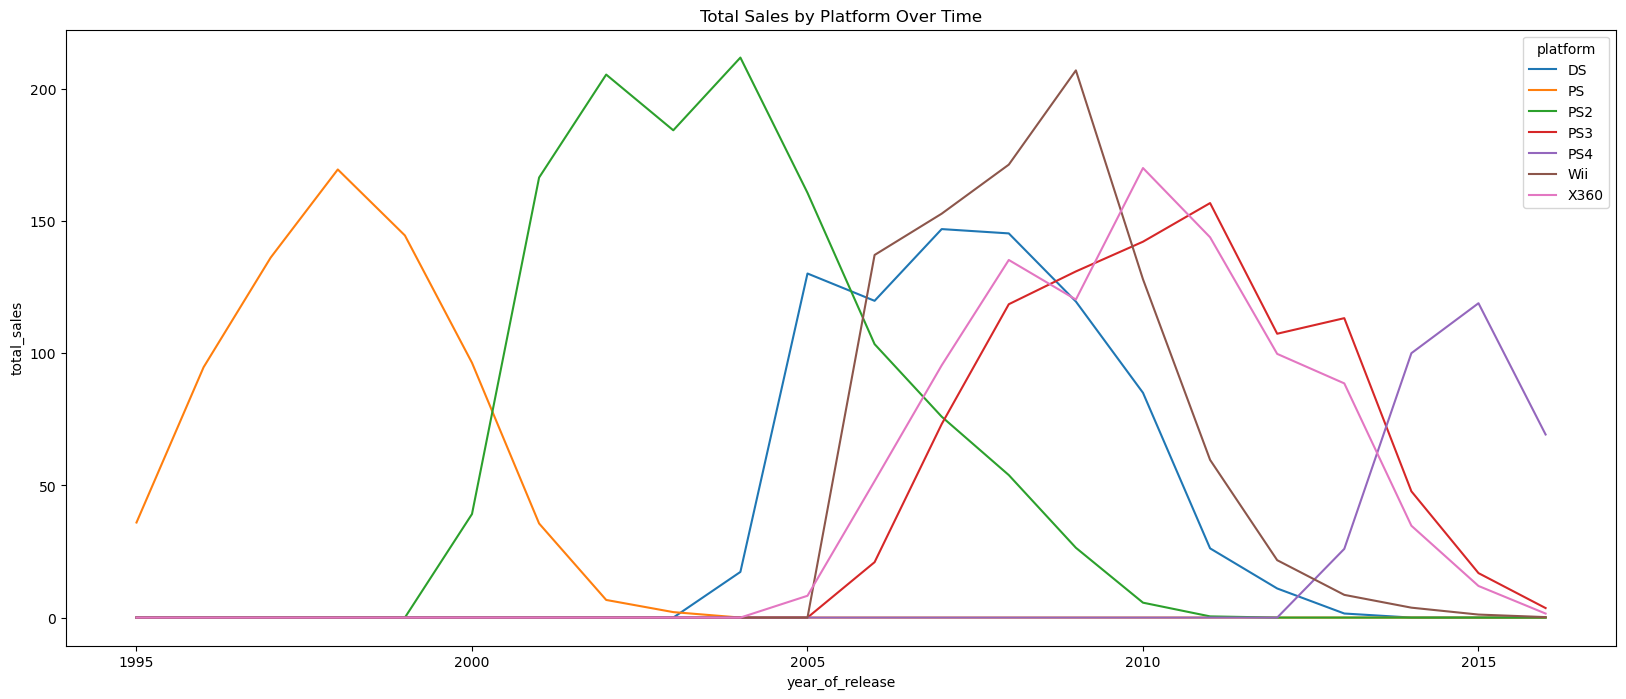

In [95]:
pivot_sales_table.plot(title = 'Total Sales by Platform Over Time', ylabel='total_sales', figsize=(20, 8)) # plotting the total sales by platform over time using the pivot table

##### From the chart above, which represents the sales volume over the years for the top 6 platforms, I conclude the following observations:
1. All six top platforms follow the same sales pattern: a gradual rise after launch until reaching their peak, followed by a progressive decline in sales until they leave the market. 
2.Their useful lifespan is around 10–12 years, with the sales peak occurring approximately 5 years after launch.
3. Another trend observed in their life cycle — clearly visible in the PlayStation platforms — is that the decline in sales coincides with the launch and growth of the next‑generation platform. There is a transition period between PS → PS2, PS2 → PS3 and now PS3 → PS4 (PS4 have decreasing sales tendency because 2016 data is not complete) allowing PlayStation to maintain an approximately stable overall sales volume.
4. The transition period ranges from 3 to 5 years, with a tendency to increase as compatibility between different console generations improves. 
5. Although this transition is only clearly visible in the PlayStation platforms within the top 6 presented, the same pattern is certainly observed in Nintendo, Microsoft or Xbox.
